In [48]:
import os
import math
import cartopy
import cartopy.crs       as ccrs
import matplotlib.pyplot as plt
import matplotlib        as mpl
import xarray            as xr
import pandas            as pd
import numpy             as np
import metpy.calc        as mpc
from matplotlib.ticker       import MaxNLocator
from datetime                import datetime, timedelta
from mpl_toolkits.axes_grid1 import make_axes_locatable,Divider,Size
from cartopy.mpl.gridliner   import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
%matplotlib inline

In [14]:
tx1 = xr.open_dataset('/Users/dpath2o/cice-dirs/runs/sandbox_tx1/history/iceh_ic.2005-01-01-03600.nc')
nc1 = xr.open_dataset('/Users/dpath2o/PHD/MODELS/CICE_runs/grids/cice_1deg_grid_from_paul.nc')

In [27]:
tx1

<xarray.Dataset>
Dimensions:       (time: 1, d2: 2, nj: 240, ni: 360, nc: 5, nkaer: 5)
Coordinates:
  * time          (time) datetime64[ns] 2005-01-01T01:00:00
    TLON          (nj, ni) float32 250.5 251.5 252.5 253.5 ... 250.0 250.0 250.0
    TLAT          (nj, ni) float32 -78.36 -78.36 -78.36 ... 62.49 62.47 62.46
    ULON          (nj, ni) float32 -109.0 -108.0 -107.0 ... -110.0 -110.0 -110.0
    ULAT          (nj, ni) float32 -78.14 -78.14 -78.14 ... 62.48 62.46 62.46
Dimensions without coordinates: d2, nj, ni, nc, nkaer
Data variables: (12/83)
    time_bounds   (time, d2) datetime64[ns] 2005-01-01 2005-01-01T01:00:00.00...
    NCAT          (nc) float32 0.6445 1.391 2.47 4.567 9.334
    VGRDa         (nkaer) float32 1.0 2.0 3.0 4.0 5.0
    tmask         (nj, ni) float32 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    blkmask       (nj, ni) float32 0.01 0.01 0.01 0.01 ... 3.04 3.04 3.04 3.04
    tarea         (nj, ni) float32 1.073e+09 1.073e+09 ... 3.289e+06 7.128e+05
    ...            ...
    hpond         (time, nj, ni) float32 nan nan nan nan nan ... nan nan nan nan
    hpond_ai      (time, nj, ni) float32 nan nan nan nan nan ... nan nan nan nan
    ipond         (time, nj, ni) float32 nan nan nan nan nan ... nan nan nan nan
    ipond_ai      (time, nj, ni) float32 nan nan nan nan nan ... nan nan nan nan
    apeff         (time, nj, ni) float32 nan nan nan nan nan ... nan nan nan nan
    apeff_ai      (time, nj, ni) float32 nan nan nan nan nan ... nan nan nan nan
Attributes:
    title:        sea ice model output for CICE
    contents:     Diagnostic and Prognostic Variables
    source:       Los Alamos Sea Ice Model, CICE_6.3.1
    comment:      This year has 365 days
    comment2:     File written on model date 20050101
    comment3:     seconds elapsed into model date:   3600
    conventions:  CF-1.0
    history:      This dataset was created on 2022-06-06 at 16:41:02.9
    io_flavor:    io_netcdf

In [28]:
nc1

<xarray.Dataset>
Dimensions:     (ny: 300, nx: 360, nc: 4)
Dimensions without coordinates: ny, nx, nc
Data variables: (12/16)
    ulat        (ny, nx) float64 ...
    ulon        (ny, nx) float64 ...
    tlat        (ny, nx) float64 ...
    tlon        (ny, nx) float64 ...
    htn         (ny, nx) float64 ...
    hte         (ny, nx) float64 ...
    ...          ...
    tarea       (ny, nx) float64 ...
    uarea       (ny, nx) float64 ...
    lont_bonds  (nc, ny, nx) float64 ...
    latt_bonds  (nc, ny, nx) float64 ...
    lonu_bonds  (nc, ny, nx) float64 ...
    latu_bonds  (nc, ny, nx) float64 ...

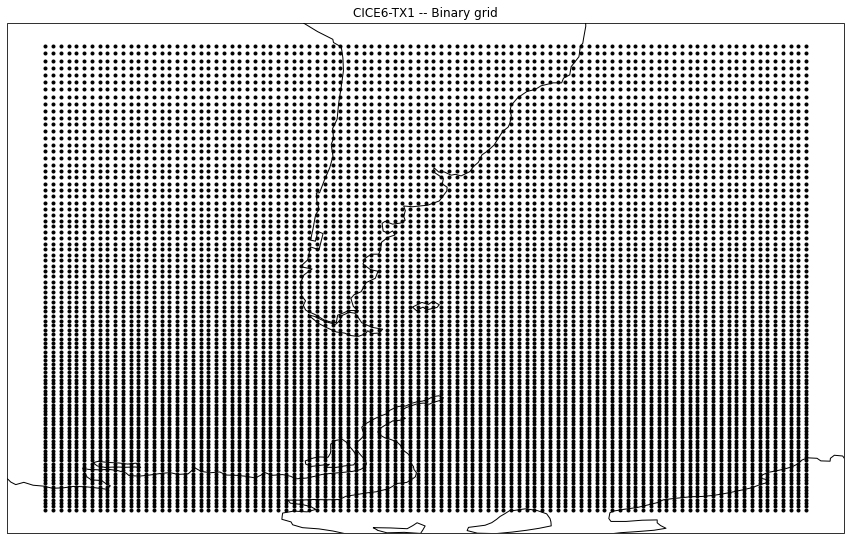

In [55]:
fig = plt.figure(figsize=(15,12))
ax  = plt.axes(projection=ccrs.PlateCarree())
lons = tx1.isel(nj=slice(1,100),ni=slice(1,100)).TLON
lats = tx1.isel(nj=slice(1,100),ni=slice(1,100)).TLAT
plt.plot(lons,lats,transform=ccrs.PlateCarree(),marker='.',linestyle='none',color='k')
ax.coastlines()
tit_str = 'CICE6-TX1 -- Binary grid'.format()
plt.title(tit_str)
plt.show()
plt.close(fig)

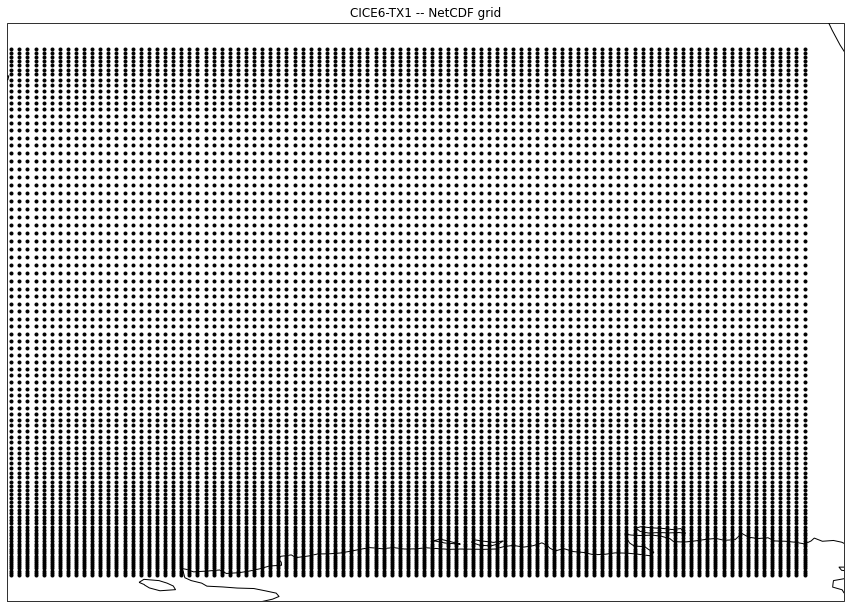

In [59]:
fig = plt.figure(figsize=(15,12))
ax  = plt.axes(projection=ccrs.PlateCarree())
lons = -np.rad2deg(nc1.isel(nx=slice(1,100),ny=slice(1,100)).tlon)
lats = np.rad2deg(nc1.isel(nx=slice(1,100),ny=slice(1,100)).tlat)
plt.plot(lons,lats,transform=ccrs.PlateCarree(),marker='.',linestyle='none',color='k')
ax.coastlines()
tit_str = 'CICE6-TX1 -- NetCDF grid'.format()
plt.title(tit_str)
plt.show()
plt.close(fig)

<xarray.DataArray 'tlon' (ny: 99, nx: 99)>
array([[278.49999784, 277.49999785, 276.49999786, ..., 182.49999859,
        181.49999859, 180.4999986 ],
       [278.49999784, 277.49999785, 276.49999786, ..., 182.49999859,
        181.49999859, 180.4999986 ],
       [278.49999784, 277.49999785, 276.49999786, ..., 182.49999859,
        181.49999859, 180.4999986 ],
       ...,
       [278.49999784, 277.49999785, 276.49999786, ..., 182.49999859,
        181.49999859, 180.4999986 ],
       [278.49999784, 277.49999785, 276.49999786, ..., 182.49999859,
        181.49999859, 180.4999986 ],
       [278.49999784, 277.49999785, 276.49999786, ..., 182.49999859,
        181.49999859, 180.4999986 ]])
Dimensions without coordinates: ny, nx
Attributes:
    units:    radians
    title:    Longitude of T points

<xarray.DataArray 'ulat' ()>
array(9848.41915685)